# Analyse et prédiction des prix Airbnb à New York

**Objectif** : comprendre ce qui détermine le prix des annonces Airbnb à New York (arrondissement, type de logement, popularité, localisation) et construire un modèle simple capable de prédire ce prix à partir des caractéristiques d'une annonce.

**Données** : jeu de données public *New York City Airbnb Open Data* (Inside Airbnb, 2019), avec colonnes traduites en français. Le notebook attend deux fichiers dans un sous-dossier `fichiers/` :
- `airbnb.csv` — les annonces (id, hôte, localisation, prix, avis, disponibilité...)
- `nyc.jpg` — un fond de carte de New York, utilisé pour la visualisation géographique

**Plan** :
1. Exploration et nettoyage des données
2. Visualisation géographique et analyse des prix
3. Modélisation prédictive du prix (régression linéaire)
4. Conclusion et pistes d'amélioration

## 0. Import des librairies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

sns.set()

TAILLE_FIGURE = 20
TAILLE_TITRE = 16
TAILLE_AXE = 14

## 1. Exploration et nettoyage des données

In [2]:
airbnb = pd.read_csv("../fichiers/Airbnb.csv")
airbnb.head()

,ID,Nom,ID proprio,Nom proprio,Arrondissement,Quartier,Latitude,Longitude,Type,Prix,Minimum nuits,Nombre avis,Dernier avis,Avis par mois,Affichages proprio,Jours disponibles annuel
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
airbnb.shape

(48895, 16)

### 1.1 Valeurs manquantes

In [4]:
airbnb.isnull().sum()

ID                              0
Nom                            16
ID proprio                      0
Nom proprio                    21
Arrondissement                  0
Quartier                        0
Latitude                        0
Longitude                       0
Type                            0
Prix                            0
Minimum nuits                   0
Nombre avis                     0
Dernier avis                10052
Avis par mois               10052
Affichages proprio              0
Jours disponibles annuel        0
dtype: int64

Deux colonnes, `Dernier avis` et `Avis par mois`, comptent exactement le même nombre de valeurs manquantes. Hypothèse : ce sont des annonces qui n'ont simplement jamais reçu d'avis. On vérifie en isolant les annonces dont `Nombre avis` vaut 0.

In [5]:
sans_avis = airbnb.loc[airbnb["Nombre avis"] == 0]
sans_avis[["Dernier avis", "Avis par mois"]].isnull().sum()

Dernier avis     10052
Avis par mois    10052
dtype: int64

Confirmé : toutes les valeurs manquantes de ces deux colonnes correspondent à des annonces sans aucun avis — il n'y a pas de date de dernier avis ni de moyenne mensuelle à calculer s'il n'y a jamais eu d'avis.

### 1.2 Propriétaires

In [6]:
airbnb["ID proprio"].nunique()

37457

In [7]:
proprietaire_frequent = airbnb["Nom proprio"].mode()[0]
print(f"Le prénom de propriétaire le plus fréquent est : {proprietaire_frequent}")

Le prénom de propriétaire le plus fréquent est : Michael


In [8]:
nb_proprio_manquant = airbnb["Nom proprio"].isnull().sum()
print(f"{nb_proprio_manquant} annonces n'ont pas de nom de propriétaire renseigné")

21 annonces n'ont pas de nom de propriétaire renseigné


On regarde aussi la concentration de la propriété : quelle part des annonces est détenue par les 10 plus gros propriétaires ?

In [9]:
listings_par_proprio = airbnb.groupby("ID proprio").size().sort_values(ascending=False)
part_top10 = listings_par_proprio.head(10).sum() / listings_par_proprio.sum() * 100
print(f"Les 10 plus gros propriétaires détiennent {part_top10:.2f}% des annonces")

Les 10 plus gros propriétaires détiennent 2.60% des annonces


### 1.3 Prix par arrondissement et par type de logement

In [10]:
prix_median_arrondissement = airbnb.pivot_table(values="Prix", index="Arrondissement", aggfunc="median")
prix_median_arrondissement

,Prix
Arrondissement,
Bronx,65.0
Brooklyn,90.0
Manhattan,150.0
Queens,75.0
Staten Island,75.0


In [11]:
prix_moyen_type = airbnb.groupby("Type")["Prix"].mean().round(2)
prix_moyen_type

Type
Entire home/apt    211.79
Private room        89.78
Shared room         70.13
Name: Prix, dtype: float64

In [12]:
airbnb.loc[
    (airbnb["Nombre avis"] > 100) & (airbnb["Arrondissement"] == "Brooklyn"), "Prix"
].mean().round(2)

np.float64(121.72)

### 1.4 Quartiers les moins chers en moyenne

In [13]:
airbnb.groupby("Quartier")["Prix"].mean().sort_values().head(3).round(2)

Quartier
Bull's Head    47.33
Hunts Point    50.50
Tremont        51.55
Name: Prix, dtype: float64

### 1.5 Contraintes de réservation

In [14]:
nb_min_365 = (airbnb["Minimum nuits"] == 365).sum()
print(f"{nb_min_365} annonces exigent un minimum de 365 nuits de réservation")

29 annonces exigent un minimum de 365 nuits de réservation


### 1.6 Avis par quartier et arrondissement

In [15]:
avis_par_quartier = (
    airbnb.groupby(["Arrondissement", "Quartier"])["Nombre avis"]
    .sum()
    .sort_values(ascending=False)
)
avis_par_quartier.head(1)

Arrondissement  Quartier          
Brooklyn        Bedford-Stuyvesant    110352
Name: Nombre avis, dtype: int64

### 1.7 Chambres partagées par arrondissement

In [16]:
repartition_type = airbnb.groupby(["Arrondissement", "Type"]).size().unstack(fill_value=0)
taux_shared = repartition_type["Shared room"] / repartition_type.sum(axis=1) * 100

print(
    f"L'arrondissement avec le taux le plus élevé de chambres partagées est "
    f"{taux_shared.idxmax()} ({taux_shared.max():.2f}% des annonces)"
)
taux_shared.sort_values(ascending=False)

L'arrondissement avec le taux le plus élevé de chambres partagées est Bronx (5.50% des annonces)


Arrondissement
Bronx            5.499542
Queens           3.494529
Staten Island    2.412869
Manhattan        2.215964
Brooklyn         2.054318
dtype: float64

### 1.8 Prix moyen selon la popularité (nombre d'avis)

In [17]:
bornes_avis = [0, 100, 200, np.inf]
labels_avis = ["< 100 avis", "100-200 avis", "> 200 avis"]
airbnb["Catégorie avis"] = pd.cut(airbnb["Nombre avis"], bins=bornes_avis, labels=labels_avis, right=False)

airbnb.groupby(["Arrondissement", "Catégorie avis"], observed=False)["Prix"].mean().round(2)

Arrondissement  Catégorie avis
Bronx           < 100 avis         88.68
                100-200 avis       70.89
                > 200 avis         67.31
Brooklyn        < 100 avis        124.60
                100-200 avis      122.28
                > 200 avis        117.97
Manhattan       < 100 avis        199.80
                100-200 avis      153.38
                > 200 avis        128.94
Queens          < 100 avis        100.56
                100-200 avis       89.10
                > 200 avis         73.53
Staten Island   < 100 avis        117.56
                100-200 avis       86.32
                > 200 avis         67.00
Name: Prix, dtype: float64

Tendance claire : plus une annonce a d'avis (donc plus elle est ancienne / populaire), plus son prix moyen est bas — probablement un effet d'ajustement des hôtes vers des prix plus compétitifs au fil du temps.

### 1.9 Ancienneté des annonces

En excluant les lignes avec valeurs manquantes, on approxime le nombre de mois d'activité d'une annonce par `Nombre avis / Avis par mois`, puis on regarde la part d'annonces actives depuis moins d'un an, par arrondissement.

In [18]:
airbnb_complet = airbnb.dropna().copy()
airbnb_complet["Mois actif"] = airbnb_complet["Nombre avis"] / airbnb_complet["Avis par mois"]

recentes = airbnb_complet["Mois actif"] < 12
proportion_recentes = (
    airbnb_complet[recentes].groupby("Arrondissement").size()
    / airbnb_complet.groupby("Arrondissement").size()
    * 100
).sort_values(ascending=False)

proportion_recentes

Arrondissement
Bronx            42.171429
Queens           40.026247
Staten Island    39.808917
Manhattan        30.906684
Brooklyn         29.460429
dtype: float64

### 1.10 Bonus — mots les plus fréquents dans les titres d'annonces

In [19]:
mots = Counter(" ".join(airbnb_complet["Nom"].str.lower()).split())
mots.most_common(5)

[('in', 13282),
 ('room', 7545),
 ('private', 5792),
 ('bedroom', 5640),
 ('apartment', 4827)]

## 2. Visualisation géographique et analyse des prix

In [20]:
df = airbnb.copy()
bornes_coord = [df["Longitude"].min(), df["Longitude"].max(), df["Latitude"].min(), df["Latitude"].max()]
carte = plt.imread("../fichiers/nyc.jpg")

On isole les annonces ayant un dernier avis daté, pour en extraire l'année et le mois — un proxy de la période de location.

In [21]:
df_dates = df.dropna(subset=["Dernier avis"]).copy()
df_dates["Dernier avis"] = pd.to_datetime(df_dates["Dernier avis"])
df_dates["Année"] = df_dates["Dernier avis"].dt.year.astype(str)
df_dates["Mois"] = df_dates["Dernier avis"].dt.month

### 2.1 Répartition géographique des annonces

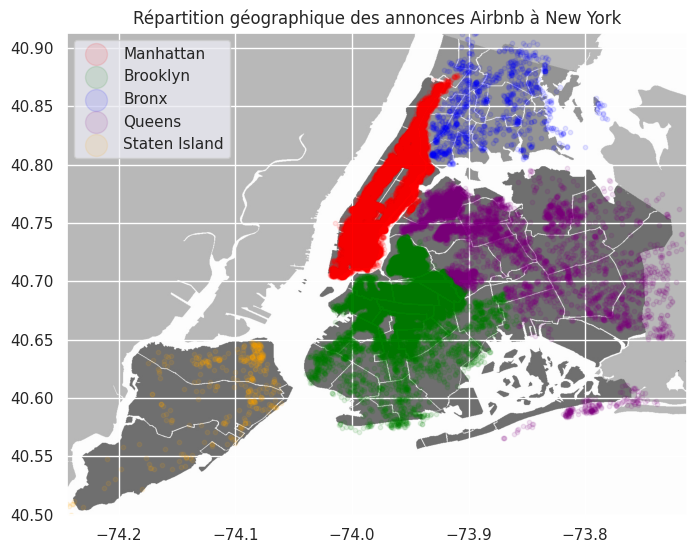

In [22]:
arrondissements = ["Manhattan", "Brooklyn", "Bronx", "Queens", "Staten Island"]
couleurs = ["red", "green", "blue", "purple", "orange"]

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(carte, extent=bornes_coord, aspect="equal")
for arr, couleur in zip(arrondissements, couleurs):
    sous_df = df[df["Arrondissement"] == arr]
    ax.scatter(sous_df["Longitude"], sous_df["Latitude"], alpha=0.1, color=couleur, s=10, label=arr)

ax.set_xlim(bornes_coord[0], bornes_coord[1])
ax.set_ylim(bornes_coord[2], bornes_coord[3])
ax.set_title("Répartition géographique des annonces Airbnb à New York")
ax.legend(markerscale=5);

### 2.2 Part des annonces par arrondissement

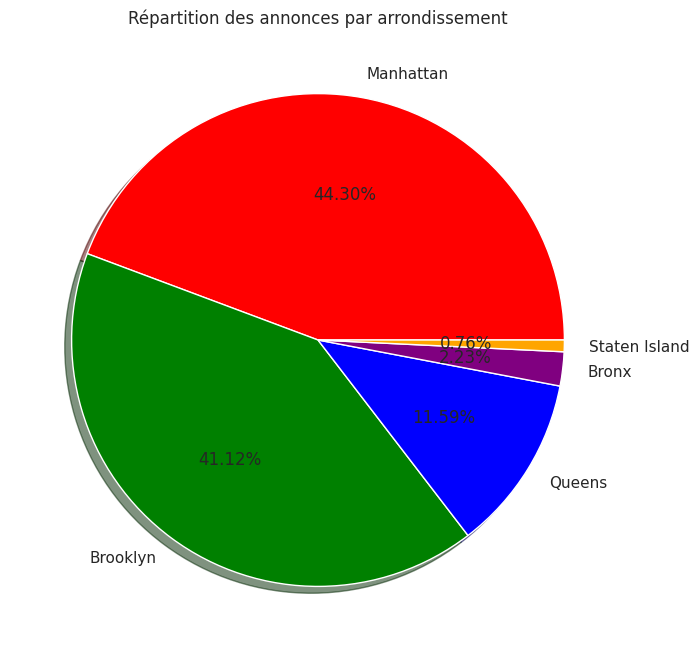

In [23]:
nb_par_arrondissement = df["Arrondissement"].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(nb_par_arrondissement, labels=nb_par_arrondissement.index, colors=couleurs, shadow=True, autopct="%1.2f%%")
ax.set_title("Répartition des annonces par arrondissement");

### 2.3 Distribution des prix par arrondissement et par type de logement

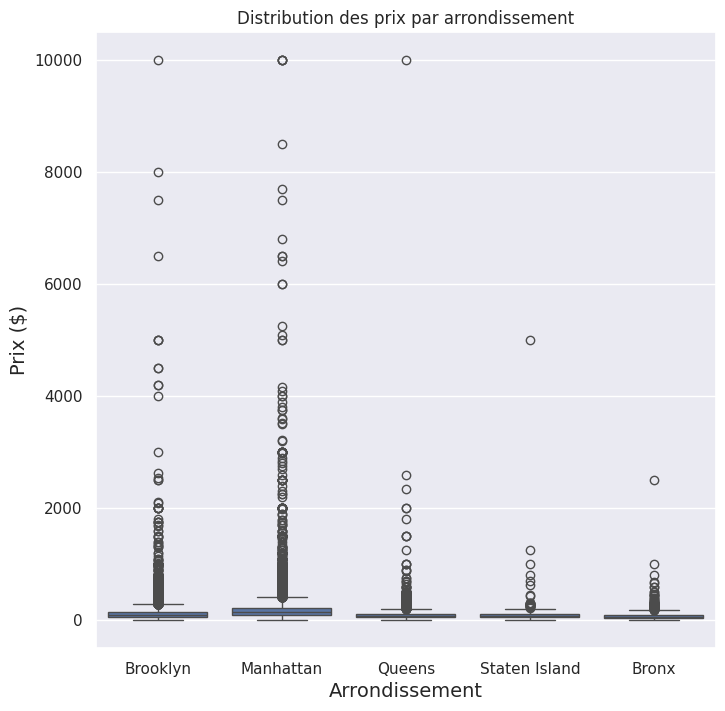

In [24]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.boxplot(x="Arrondissement", y="Prix", data=df, ax=ax)
ax.set_title("Distribution des prix par arrondissement")
ax.set_xlabel("Arrondissement", fontsize=TAILLE_AXE)
ax.set_ylabel("Prix ($)", fontsize=TAILLE_AXE);

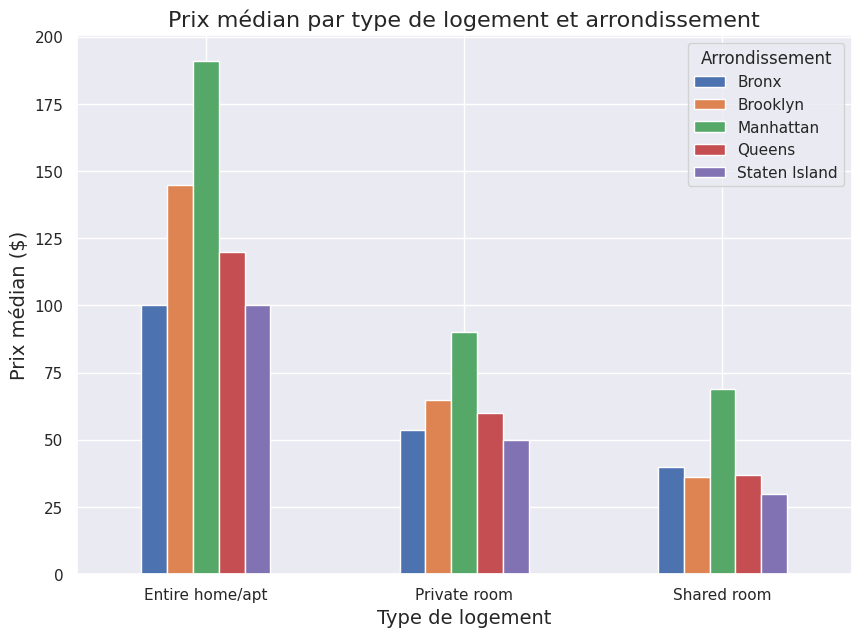

In [25]:
prix_median_type_arr = df.pivot_table("Prix", index="Arrondissement", columns="Type", aggfunc="median", fill_value=0)

fig, ax = plt.subplots(figsize=(10, 7))
prix_median_type_arr.T.plot.bar(ax=ax)
ax.set_title("Prix médian par type de logement et arrondissement", fontsize=TAILLE_TITRE)
ax.set_xlabel("Type de logement", fontsize=TAILLE_AXE)
ax.set_ylabel("Prix médian ($)", fontsize=TAILLE_AXE)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, horizontalalignment="center");

Manhattan se distingue nettement des autres arrondissements, quel que soit le type de logement — cohérent avec son statut de quartier d'affaires et touristique central.

### 2.4 Distribution des prix par type de logement

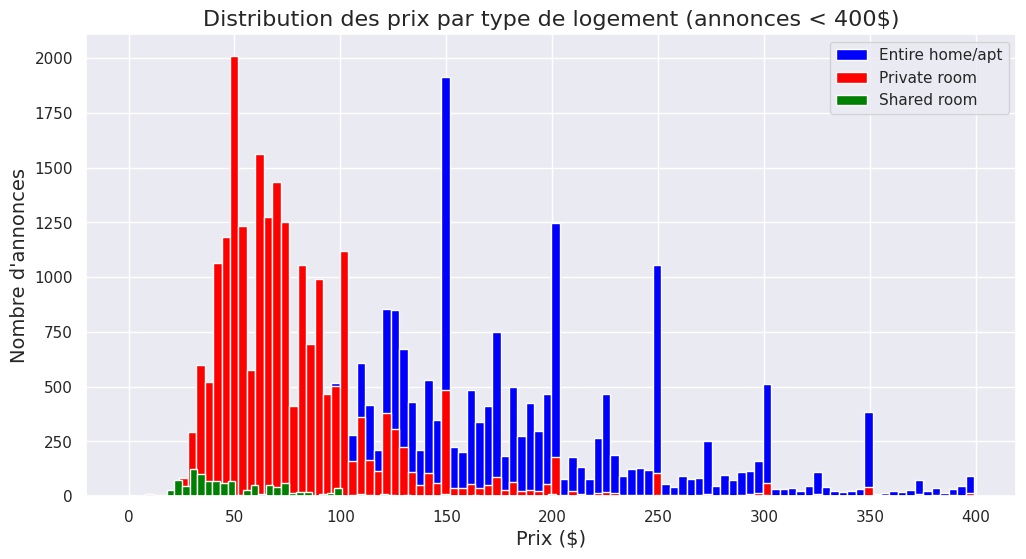

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))
for type_logement, couleur in zip(["Entire home/apt", "Private room", "Shared room"], ["blue", "red", "green"]):
    df[(df["Prix"] < 400) & (df["Type"] == type_logement)]["Prix"].hist(
        bins=100, color=couleur, label=type_logement, ax=ax
    )

ax.set_title("Distribution des prix par type de logement (annonces < 400$)", fontsize=TAILLE_TITRE)
ax.set_xlabel("Prix ($)", fontsize=TAILLE_AXE)
ax.set_ylabel("Nombre d'annonces", fontsize=TAILLE_AXE)
ax.legend();

On observe des pics réguliers (multiples de 25$ ou 50$) — les hôtes ont tendance à fixer des prix ronds plutôt que des prix optimisés au dollar près.

### 2.5 Évolution temporelle du nombre d'annonces et du prix médian

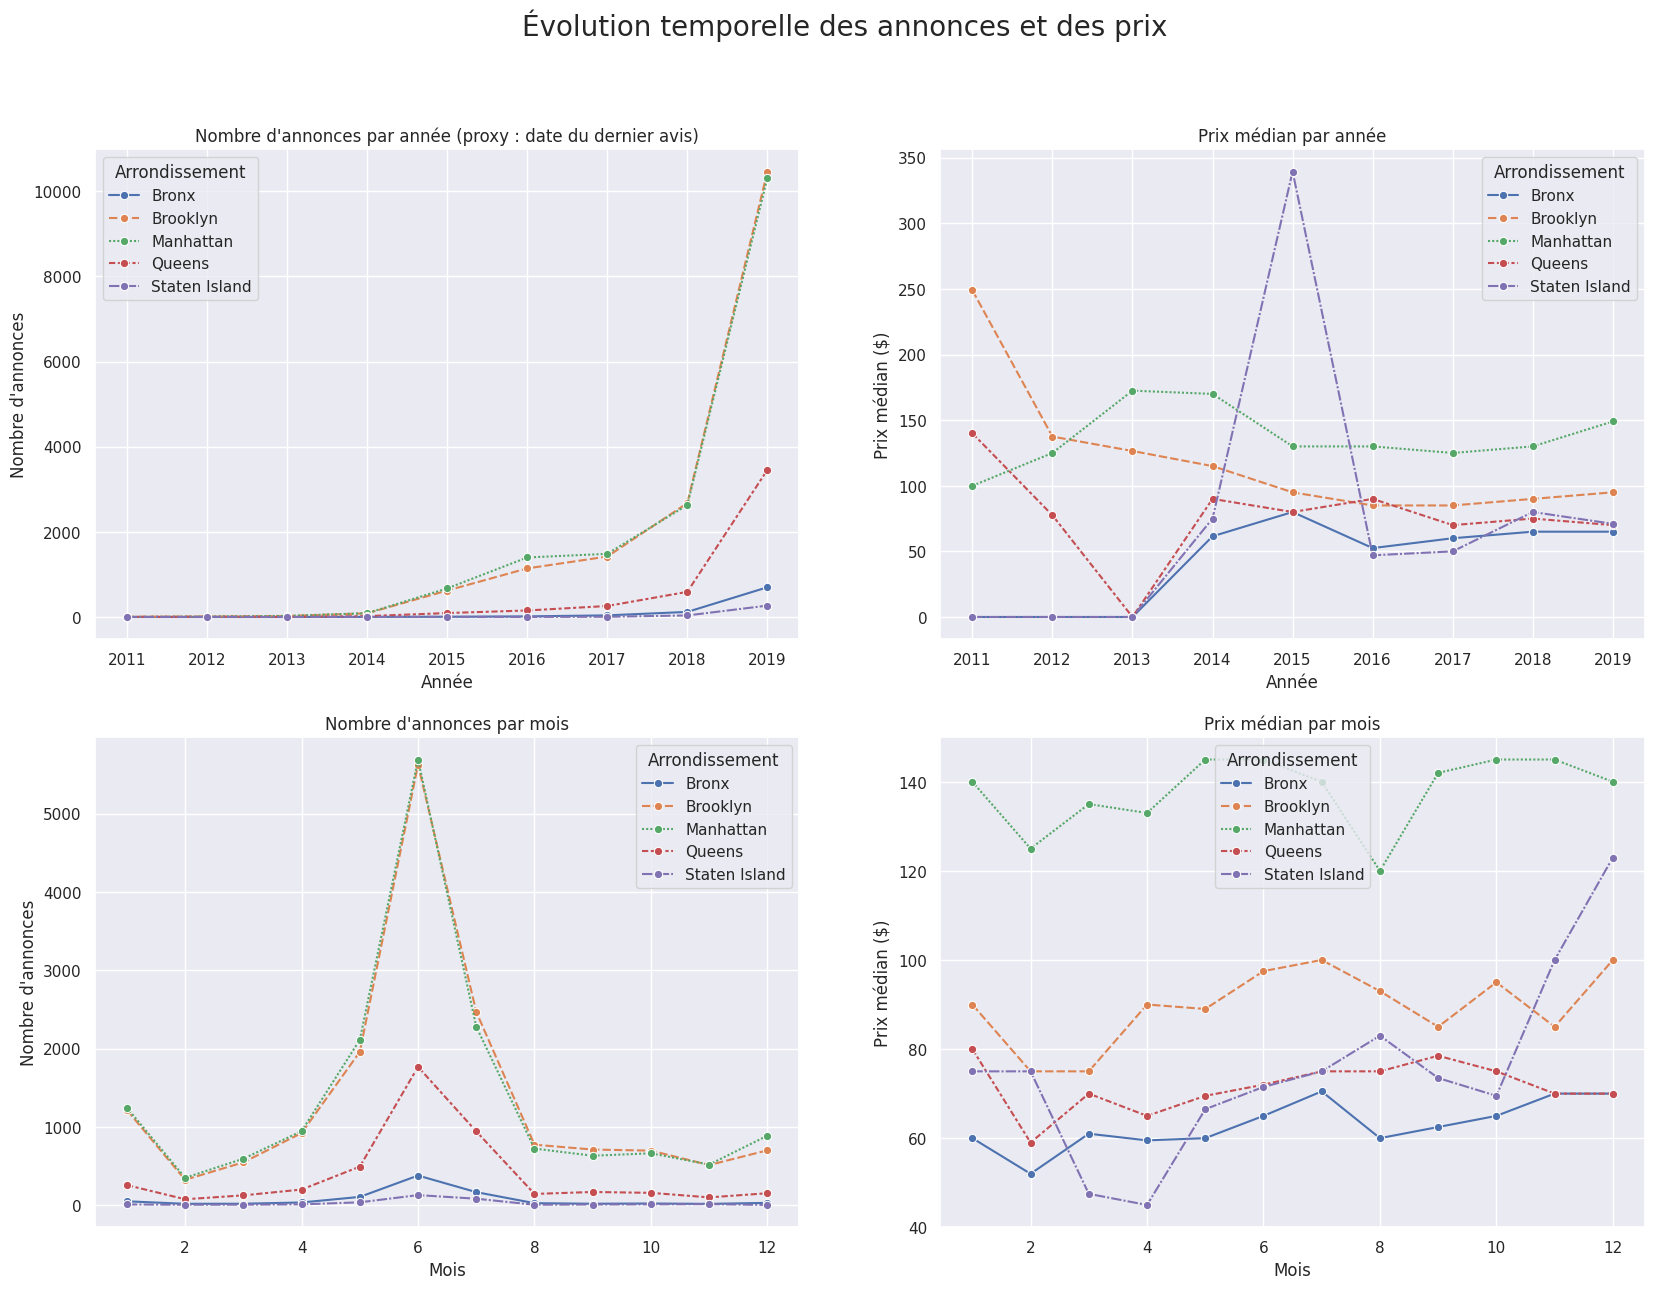

In [27]:
nb_par_annee = df_dates.pivot_table("Prix", index="Année", columns="Arrondissement", aggfunc="count", fill_value=0)
prix_median_par_annee = df_dates.pivot_table("Prix", index="Année", columns="Arrondissement", aggfunc="median", fill_value=0)
nb_par_mois = df_dates.pivot_table("Prix", index="Mois", columns="Arrondissement", aggfunc="count", fill_value=0)
prix_median_par_mois = df_dates.pivot_table("Prix", index="Mois", columns="Arrondissement", aggfunc="median", fill_value=0)

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
sns.lineplot(data=nb_par_annee, marker="o", ax=axes[0][0])
sns.lineplot(data=prix_median_par_annee, marker="o", ax=axes[0][1])
sns.lineplot(data=nb_par_mois, marker="o", ax=axes[1][0])
sns.lineplot(data=prix_median_par_mois, marker="o", ax=axes[1][1])

axes[0][0].set(title="Nombre d'annonces par année (proxy : date du dernier avis)", xlabel="Année", ylabel="Nombre d'annonces")
axes[0][1].set(title="Prix médian par année", xlabel="Année", ylabel="Prix médian ($)")
axes[1][0].set(title="Nombre d'annonces par mois", xlabel="Mois", ylabel="Nombre d'annonces")
axes[1][1].set(title="Prix médian par mois", xlabel="Mois", ylabel="Prix médian ($)")
fig.suptitle("Évolution temporelle des annonces et des prix", fontsize=TAILLE_FIGURE);

Deux constats principaux :
- Forte croissance du nombre d'annonces entre 2017 et 2019, cohérente avec l'essor de la plateforme.
- Le prix médian reste globalement stable sur la même période — la croissance de l'offre ne semble pas avoir fait pression sur les prix.

Attention à un biais de sélection : la courbe de Staten Island en 2015 repose sur un échantillon de seulement 4 annonces, ce qui la rend peu fiable pour cette année-là.

### 2.6 Durée minimale de réservation exigée

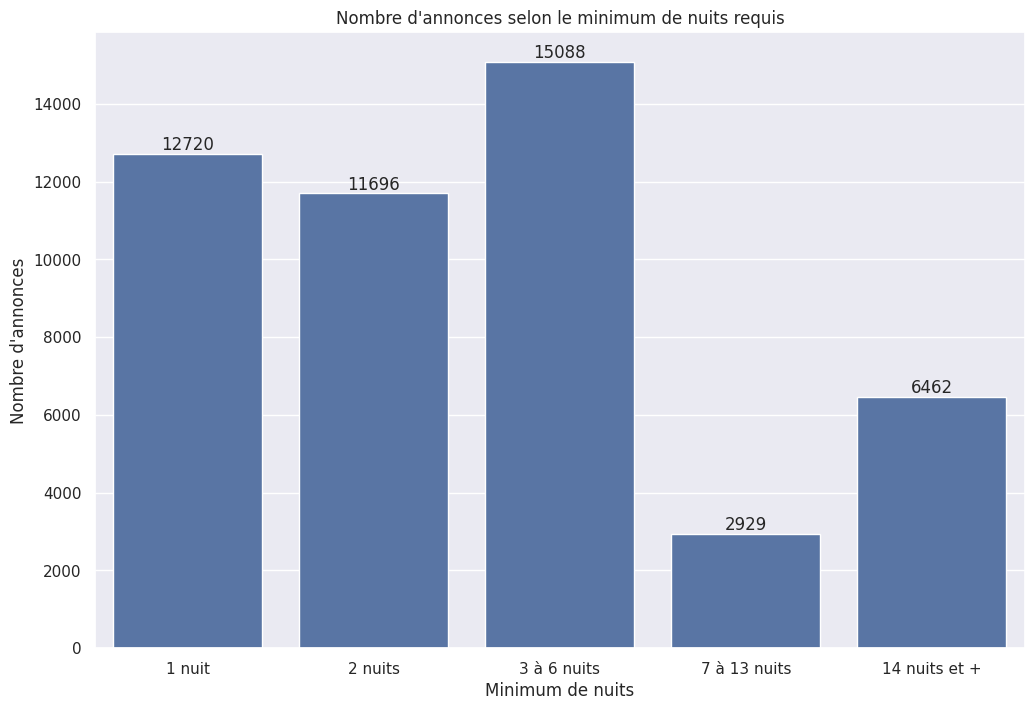

In [28]:
bornes_nuits = [0, 1, 2, 6, 13, np.inf]
labels_nuits = ["1 nuit", "2 nuits", "3 à 6 nuits", "7 à 13 nuits", "14 nuits et +"]
df["Catégorie nuits"] = pd.cut(df["Minimum nuits"], bins=bornes_nuits, labels=labels_nuits)

fig, ax = plt.subplots(figsize=(12, 8))
graphe = sns.countplot(x=df["Catégorie nuits"], order=labels_nuits, ax=ax)
ax.set_title("Nombre d'annonces selon le minimum de nuits requis")
ax.set_xlabel("Minimum de nuits")
ax.set_ylabel("Nombre d'annonces")

for p in graphe.patches:
    hauteur = p.get_height()
    graphe.text(p.get_x() + p.get_width() / 2, hauteur, f"{int(hauteur)}", ha="center", va="bottom")

### 2.7 Distance aux grands parcs (feature engineering géospatial)

On calcule la distance (en km) entre chaque annonce et deux points de référence — Central Park et Prospect Park — via la formule de Haversine, pour voir si la proximité d'un grand parc influence le prix.

In [29]:
def distance_haversine(lat1, lon1, lat2, lon2):
    """Distance approximative en km entre deux points GPS."""
    return np.arccos(
        np.sin(np.radians(lat1)) * np.sin(np.radians(lat2))
        + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.cos(np.radians(lon1 - lon2))
    ) * 6371


lat_central_park, lon_central_park = 40.785091, -73.968285
lat_prospect_park, lon_prospect_park = 40.665535, -73.969749

df["Distance Central Park"] = distance_haversine(
    lat_central_park, lon_central_park, df["Latitude"], df["Longitude"]
).round(4)
df["Distance Prospect Park"] = distance_haversine(
    lat_prospect_park, lon_prospect_park, df["Latitude"], df["Longitude"]
).round(4)

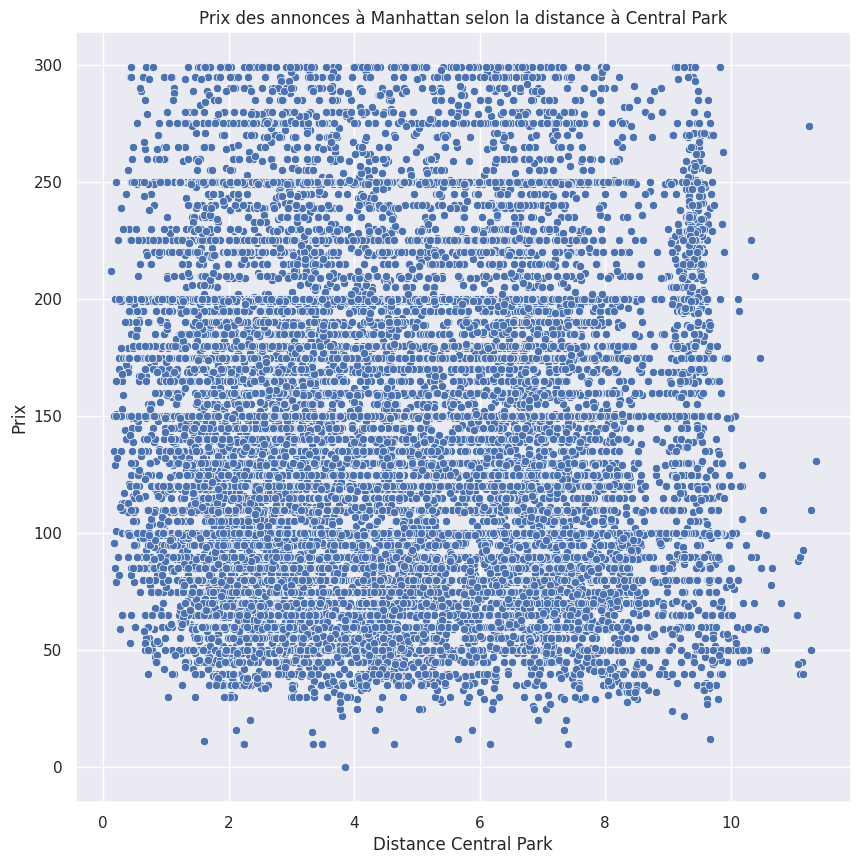

In [30]:
manhattan_proche_cp = df[(df["Arrondissement"] == "Manhattan") & (df["Prix"] < 300)]

fig, ax = plt.subplots(figsize=(10, 10))
sns.scatterplot(x="Distance Central Park", y="Prix", data=manhattan_proche_cp, ax=ax)
ax.set_title("Prix des annonces à Manhattan selon la distance à Central Park");

## 3. Modélisation prédictive du prix

Objectif : prédire le `Prix` d'une annonce à partir de son type de logement, son arrondissement, ses contraintes de réservation et sa popularité — sans utiliser d'information géographique fine (quartier, latitude/longitude) ni de texte, pour garder un modèle simple et généralisable.

In [31]:
df["Mois actif"] = df["Nombre avis"] / df["Avis par mois"]

variables_explicatives = ["Type", "Arrondissement", "Minimum nuits", "Nombre avis", "Jours disponibles annuel", "Mois actif"]
X = df[variables_explicatives]
y = df["Prix"]

variables_num = list(X.select_dtypes(exclude=["object"]))
variables_cat = list(X.select_dtypes(include=["object"]))

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=1)
print(f"Entraînement : {X_train.shape}, Validation : {X_val.shape}")

Entraînement : (36671, 6), Validation : (12224, 6)


### 3.1 Imputation, encodage et standardisation

In [32]:
index_train, index_val = X_train.index, X_val.index

# Imputation des variables numériques (médiane) et catégorielles (mode), calibrée sur l'entraînement uniquement
imp_num = SimpleImputer(strategy="median").fit(X_train[variables_num])
X_train_num = pd.DataFrame(imp_num.transform(X_train[variables_num]), columns=variables_num, index=index_train)
X_val_num = pd.DataFrame(imp_num.transform(X_val[variables_num]), columns=variables_num, index=index_val)

imp_cat = SimpleImputer(strategy="most_frequent").fit(X_train[variables_cat])
X_train_cat = pd.DataFrame(imp_cat.transform(X_train[variables_cat]), columns=variables_cat, index=index_train)
X_val_cat = pd.DataFrame(imp_cat.transform(X_val[variables_cat]), columns=variables_cat, index=index_val)

X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_val = pd.concat([X_val_num, X_val_cat], axis=1)

In [33]:
# Encodage one-hot des variables catégorielles
encodeur = ColumnTransformer(
    transformers=[("encoder", OneHotEncoder(drop="first"), variables_cat)],
    remainder="passthrough",
)
X_train = pd.DataFrame(encodeur.fit_transform(X_train), columns=encodeur.get_feature_names_out(), index=index_train)
X_val = pd.DataFrame(encodeur.transform(X_val), columns=encodeur.get_feature_names_out(), index=index_val)

colonnes_encodees = X_train.columns

# Standardisation robuste (moins sensible aux valeurs extrêmes que StandardScaler)
standardiseur = RobustScaler().fit(X_train)
X_train = pd.DataFrame(standardiseur.transform(X_train), columns=colonnes_encodees, index=index_train)
X_val = pd.DataFrame(standardiseur.transform(X_val), columns=colonnes_encodees, index=index_val)

### 3.2 Analyse des corrélations

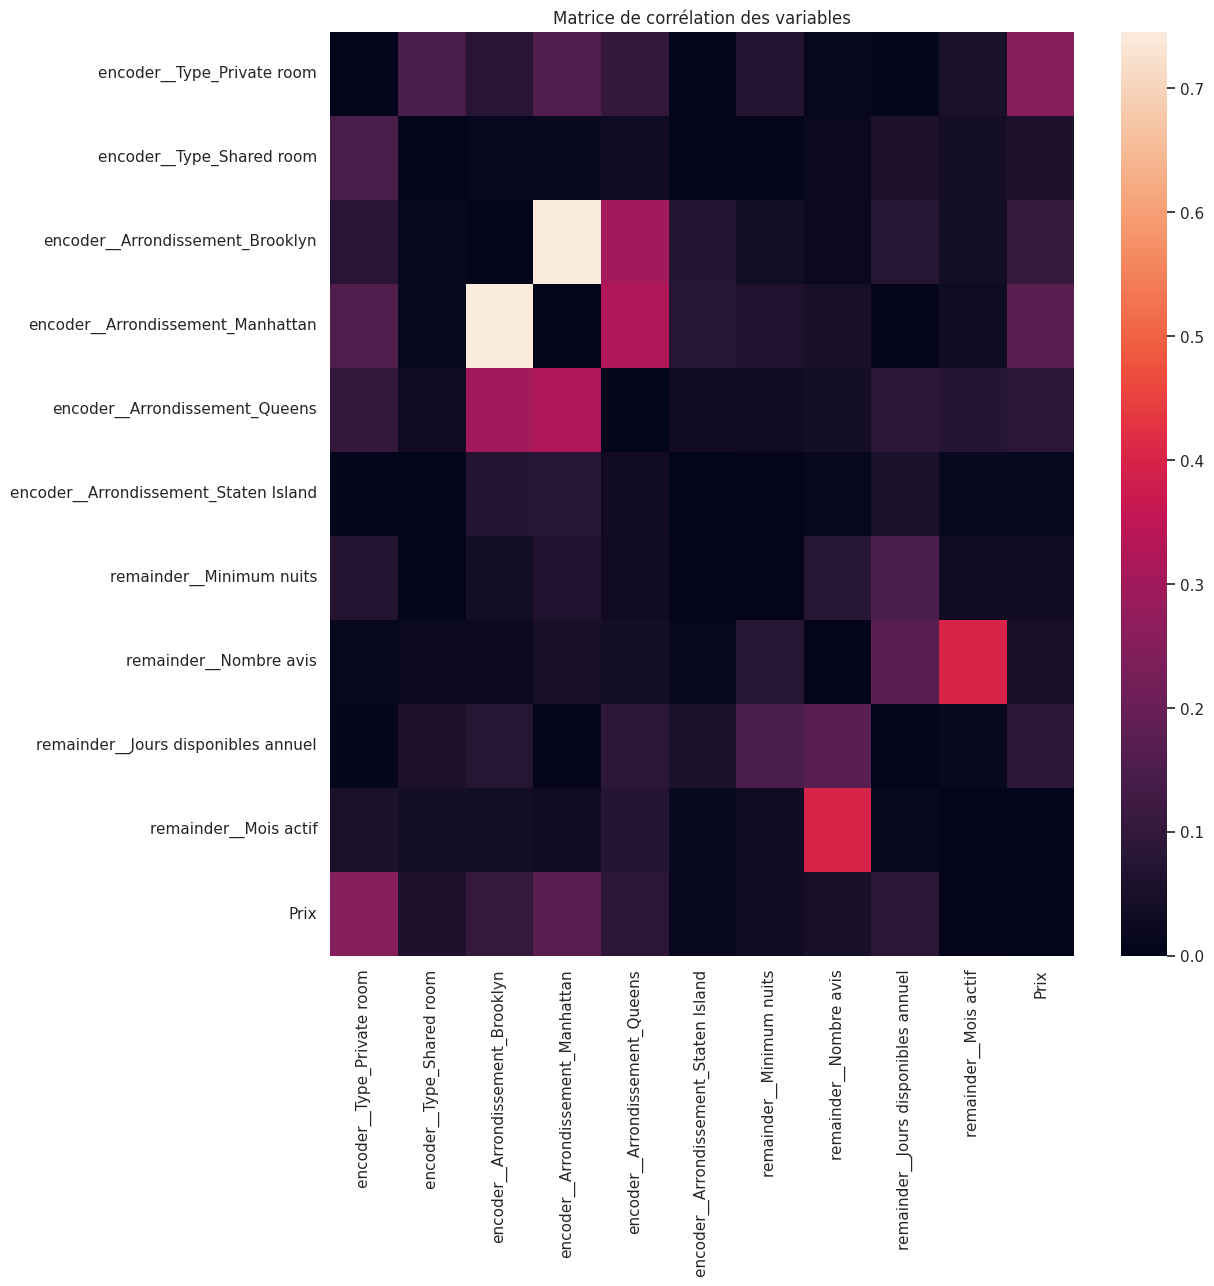

In [34]:
train = pd.concat([X_train, y_train], axis=1)
corr_matrix = train.corr().abs()
np.fill_diagonal(corr_matrix.values, 0)

fig, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(corr_matrix, ax=ax)
ax.set_title("Matrice de corrélation des variables");

In [35]:
colonnes_correlees = [col for col in corr_matrix.columns if any(corr_matrix[col] > 0.6)]
print(f"{len(colonnes_correlees)} colonne(s) avec une corrélation > 0.6 avec au moins une autre variable : {colonnes_correlees}")

2 colonne(s) avec une corrélation > 0.6 avec au moins une autre variable : ['encoder__Arrondissement_Brooklyn', 'encoder__Arrondissement_Manhattan']


Sans surprise, les indicatrices d'un même arrondissement sont corrélées entre elles (encodage one-hot). On retire l'une des colonnes redondantes pour limiter la colinéarité et on compare les deux versions du modèle.

In [36]:
colonnes_a_retirer = [c for c in colonnes_correlees if "Brooklyn" in c]
X_train_corr = X_train.drop(columns=colonnes_a_retirer)
X_val_corr = X_val.drop(columns=colonnes_a_retirer)
print(f"Colonne(s) retirée(s) : {colonnes_a_retirer}")

Colonne(s) retirée(s) : ['encoder__Arrondissement_Brooklyn']


### 3.3 Entraînement et comparaison des modèles

In [37]:
modele_complet = LinearRegression().fit(X_train, y_train)
modele_reduit = LinearRegression().fit(X_train_corr, y_train)

y_pred_complet = modele_complet.predict(X_val)
y_pred_reduit = modele_reduit.predict(X_val_corr)

mae_complet = mean_absolute_error(y_val, y_pred_complet)
mae_reduit = mean_absolute_error(y_val, y_pred_reduit)

print(f"Erreur absolue moyenne (MAE) - modèle complet         : {mae_complet:.2f} $")
print(f"Erreur absolue moyenne (MAE) - modèle sans colinéarité : {mae_reduit:.2f} $")

Erreur absolue moyenne (MAE) - modèle complet         : 74.90 $
Erreur absolue moyenne (MAE) - modèle sans colinéarité : 74.94 $


La MAE se lit en dollars : c'est l'écart moyen, en valeur absolue, entre le prix prédit et le prix réel d'une annonce.

### 3.4 Analyse des écarts de prédiction

In [38]:
resultats = pd.DataFrame({"Prix réel": y_val, "Prix prédit": y_pred_reduit})
resultats["Écart relatif"] = (resultats["Prix prédit"] - resultats["Prix réel"]) / resultats["Prix réel"]
resultats.sort_values("Écart relatif", ascending=False).head(10)

,Prix réel,Prix prédit,Écart relatif
25753,0,54.809924,inf
25634,0,53.612971,inf
33225,10,207.177976,19.717798
35601,10,171.650478,16.165048
21281,12,194.114833,15.176236
28242,12,172.341053,13.361754
31066,10,115.998323,10.599832
34446,10,91.553633,8.155363
33505,10,73.765968,6.376597
7235,37,239.067715,5.461290


## 4. Conclusion et pistes d'amélioration

**Principaux constats** :
- Le prix d'une annonce Airbnb à New York dépend fortement de l'arrondissement (Manhattan très au-dessus du reste) et du type de logement (logement entier > chambre privée > chambre partagée).
- La popularité (nombre d'avis) est associée à des prix plus bas, ce qui suggère un ajustement des hôtes vers des prix plus compétitifs avec le temps.
- Le marché a connu une forte croissance en nombre d'annonces entre 2017 et 2019 sans hausse correspondante du prix médian.
- Un modèle de régression linéaire simple, basé uniquement sur le type de logement, l'arrondissement, la disponibilité et la popularité, permet déjà de capturer une partie du signal, mais laisse une marge d'erreur significative — attendue étant donné l'absence de variables comme la taille du logement ou les équipements.

**Pistes d'amélioration** :
- Transformer `Prix` (log) pour réduire l'asymétrie de sa distribution avant modélisation.
- Tester des modèles non linéaires (Random Forest, Gradient Boosting) capables de capter des interactions entre variables.
- Exploiter la localisation précise (quartier, distance aux points d'intérêt) plutôt que le seul arrondissement.
- Valider les résultats par validation croisée plutôt qu'un split unique train/validation.